# Model Building

## Objective

Train a Random Forest classifier to detect anomalies in industrial water treatment systems using the SWaT dataset.

The model will classify each observation as either:

- Normal
- Attack

A time-aware train/test split is used to preserve the temporal characteristics of the process.

In [1]:
import pandas as pd
import numpy as np


from pathlib import Path

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt

import joblib

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "swat_features.csv"

df = pd.read_csv(DATA_PATH)

feature_cols = [c for c in df.columns if c != "Target"]

df[feature_cols] = df[feature_cols].astype(np.float32)

df["Target"] = df["Target"].astype(np.int8)

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1441719 entries, 0 to 1441718
Data columns (total 52 columns):
 #   Column   Non-Null Count    Dtype  
---  ------   --------------    -----  
 0   FIT101   1441719 non-null  float32
 1   LIT101   1441719 non-null  float32
 2   MV101    1441719 non-null  float32
 3   P101     1441719 non-null  float32
 4   P102     1441719 non-null  float32
 5   AIT201   1441719 non-null  float32
 6   AIT202   1441719 non-null  float32
 7   AIT203   1441719 non-null  float32
 8   FIT201   1441719 non-null  float32
 9   MV201    1441719 non-null  float32
 10  P201     1441719 non-null  float32
 11  P202     1441719 non-null  float32
 12  P203     1441719 non-null  float32
 13  P204     1441719 non-null  float32
 14  P205     1441719 non-null  float32
 15  P206     1441719 non-null  float32
 16  DPIT301  1441719 non-null  float32
 17  FIT301   1441719 non-null  float32
 18  LIT301   1441719 non-null  float32
 19  MV301    1441719 non-null  float32
 20  MV

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="Target")
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
    shuffle=True
)

print("Train Shape :", X_train.shape)
print("Test Shape  :", X_test.shape)

print("\nTrain Distribution")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest Distribution")
print(y_test.value_counts(normalize=True) * 100)

Train Shape : (1153375, 51)
Test Shape  : (288344, 51)

Train Distribution
Target
0    96.21138
1     3.78862
Name: proportion, dtype: float64

Test Distribution
Target
0    96.21147
1     3.78853
Name: proportion, dtype: float64


In [4]:
# ==========================================
# Train Random Forest Classifier
# ==========================================

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [5]:
# ==========================================
# Prediction
# ==========================================

y_pred = rf.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [6]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9993


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    277420
           1       0.98      1.00      0.99     10924

    accuracy                           1.00    288344
   macro avg       0.99      1.00      1.00    288344
weighted avg       1.00      1.00      1.00    288344



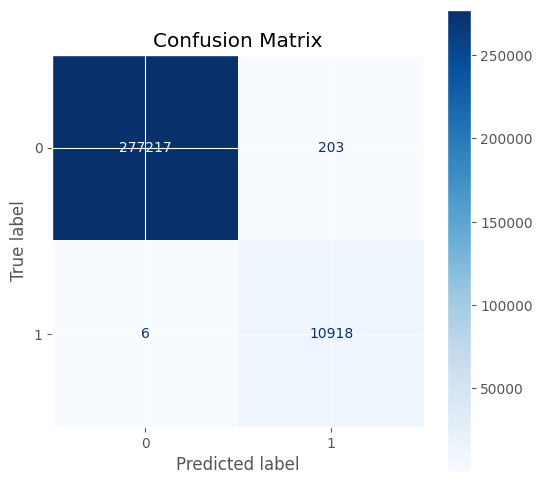

In [8]:
fig, ax = plt.subplots(figsize=(6,6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix")

plt.show()

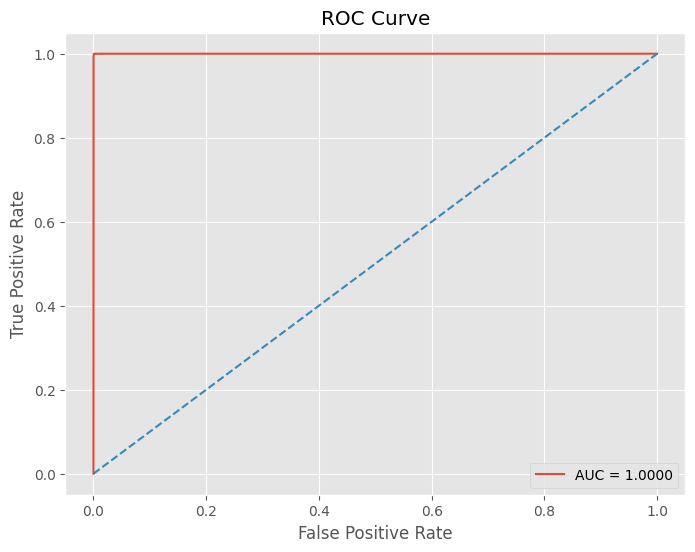

In [9]:
y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [10]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
37,AIT504,0.096426
46,PIT503,0.088468
44,PIT501,0.080357
34,AIT501,0.067756
26,AIT402,0.066650
5,AIT201,0.060415
38,FIT501,0.047756
40,FIT503,0.043995
35,AIT502,0.043334
45,PIT502,0.041301


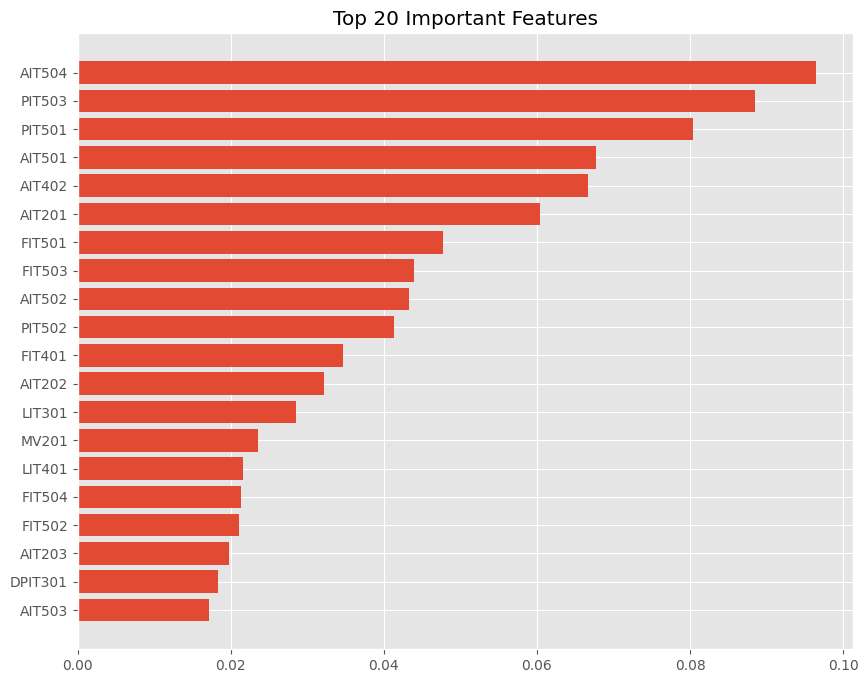

In [11]:
plt.figure(figsize=(10,8))

plt.barh(
    importance["Feature"][:20],
    importance["Importance"][:20]
)

plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")

plt.show()

In [12]:
import joblib

MODEL_PATH = PROJECT_ROOT / "models"

MODEL_PATH.mkdir(exist_ok=True)

joblib.dump(
    rf,
    MODEL_PATH / "random_forest.pkl"
)

print("Model Saved Successfully.")

Model Saved Successfully.


In [13]:
print(rf)

RandomForestClassifier(class_weight='balanced', max_depth=15, n_estimators=200,
                       n_jobs=-1, random_state=42)


In [14]:
importance.head(20)

,Feature,Importance
37,AIT504,0.096426
46,PIT503,0.088468
44,PIT501,0.080357
34,AIT501,0.067756
26,AIT402,0.066650
5,AIT201,0.060415
38,FIT501,0.047756
40,FIT503,0.043995
35,AIT502,0.043334
45,PIT502,0.041301


In [15]:
RESULTS_PATH = PROJECT_ROOT / "results"

RESULTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [16]:
importance.to_csv(
    PROJECT_ROOT / "results" / "feature_importance.csv",
    index=False
)

## Conclusion

The Random Forest classifier achieved excellent performance on the SWaT dataset.

Key observations:

- Accuracy: 99.93%
- Recall for attack detection: 100%
- Precision for attack detection: 98%
- The model is suitable as a baseline classifier for industrial anomaly detection.

Future work:

- XGBoost
- Isolation Forest
- LSTM Autoencoder
- Explainable AI (SHAP)

In [ ]:
from pathlib import Path
import pandas as pd


PROJECT_ROOT = Path.cwd().parent


processed_path = PROJECT_ROOT / "data" / "processed"
processed_path.mkdir(parents=True, exist_ok=True)


train_df = X_train.copy()
train_df["Target"] = y_train.values


test_df = X_test.copy()
test_df["Target"] = y_test.values


train_df.to_csv(
    processed_path / "train_data.csv",
    index=False
)

test_df.to_csv(
    processed_path / "test_data.csv",
    index=False
)

print("✅ Files saved successfully.")
print(f"Train -> {processed_path / 'train_data.csv'}")
print(f"Test  -> {processed_path / 'test_data.csv'}")